# Abrindo

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

from IPython.display import display

In [14]:
# Configura para mostrar todas as linhas e colunas do DataFrame
pd.set_option('display.max_rows', None)  # Exibe todas as linhas
pd.set_option('display.max_columns', None)  # Exibe todas as colunas
pd.set_option('display.width', None)  # Ajusta a largura da exibição

In [16]:
# Caminho para o arquivo Parquet
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

# Ler o arquivo Parquet
df = pd.read_parquet(caminho_parquet)

In [19]:
df.head(1)

,Dt_Hr,timestamp,Lat,Long,Alt,Precip,Pres_Atm,Pres_Atm_max,Pres_Atm_min,Rad,Temp_Amb,Pto_Orv,Temp_Amb_max,Temp_Amb_min,Pto_Orv_max,Pto_Orv_min,Umidade_max,Umidade_min,Umidade,Vento_dir,Vento_raj,Vento_vel,ESTACAO,estacao_do_ano,hora,turno,PRECIPITAÇÃO TOTAL primeira hora anterior,PRECIPITAÇÃO TOTAL segunda hora anterior,PRECIPITAÇÃO TOTAL terceira hora anterior,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,VARIACAO QUARTA HORA ANTERIOR PRESSAO,VARIACAO QUINTA HORA ANTERIOR PRESSAO,VARIACAO SEXTA HORA ANTERIOR PRESSAO,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD
0,2007-05-18,1.179457e+09,-22.988333,-43.190278,42.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,FORTE_COPACABANA,Outono,0,Noite,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN


# Funções

In [31]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_ORVALHO_2H_ATRAS'] = (
        grupo['Pto_Orv_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Pto_Orv_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_ORVALHO_3H_ATRAS'] = (
        grupo['Pto_Orv_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Pto_Orv_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo

In [58]:
# Função principal de processamento para a estação
def processar_estacao(df, estacao):
    # Filtra os dados pela estação
    estacao_df = df[df['ESTACAO'] == estacao]

    # Variáveis que quero usar
    variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pto_Orv_max','Pto_Orv_min',
                 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
                 'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO',
                 'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO']

    estacao_df = estacao_df[variaveis]

    # Substitui os valores -9999 por NaN
    estacao_df.replace(-9999, np.nan, inplace=True)

    # Conta a quantidade de valores nulos em cada coluna
    missing_values = estacao_df.isnull().sum()
    print(missing_values)

    # Total de valores nulos no DataFrame
    total_missing_values = estacao_df.isnull().sum().sum()
    print("Total de valores nulos no DataFrame:", total_missing_values)

    estacao_df = estacao_df.reset_index(drop=True)

    # Remover linhas com valores nulos nas colunas Precip e Pto_Orv_min
    estacao_df = estacao_df.dropna(subset=['Precip'])
    estacao_df = estacao_df.dropna(subset=['Pto_Orv_min'])
    estacao_df = estacao_df.dropna(subset=['Pto_Orv_max'])


    # Aplicar a função calcular_maior_diferenca na estação
    estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

    # Separa chuvas normais e extremas
    estacao_chuva = estacao_df[(estacao_df['Precip'] > 0) & (estacao_df['Precip'] < 25)]
    estacao_chuva_extrema = estacao_df[estacao_df['Precip'] >= 25]

    # Seleciona variáveis de interesse para a correlação
    variaveis_corr = ['Precip',
                      'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
                      'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO',
                      'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
                      'MAIOR_DIFERENCA_ORVALHO_2H_ATRAS',
                      'MAIOR_DIFERENCA_ORVALHO_3H_ATRAS']

    estacao_chuva = estacao_chuva[estacao_chuva['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'] <= 500]
    estacao_chuva = estacao_chuva[estacao_chuva['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO'] <= 500]
    estacao_chuva = estacao_chuva[estacao_chuva['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO'] <= 500]

  

    # Calcula a matriz de correlação para chuvas normais
    correlation_matrix_chuva = estacao_chuva[variaveis_corr].corr()

    # Gera o gráfico de correlação para chuvas normais
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation_matrix_chuva, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Matriz de Correlação entre chuvas normais e variação de temperatura do ponto de orvalho para {estacao}')
    plt.show()

    # Calcula a matriz de correlação para chuvas extremas
    correlation_matrix_chuva_extrema = estacao_chuva_extrema[variaveis_corr].corr()

    # Gera o gráfico de correlação para chuvas extremas
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation_matrix_chuva_extrema, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Matriz de Correlação entre chuvas extremas e variação de temperatura do ponto de orvalho para {estacao}')
    plt.show()

    print(f"\nEstatísticas Descritivas para Chuvas Normais em {estacao}:")
    display(estacao_chuva[variaveis_corr].describe())

    print(f"\nEstatísticas Descritivas para Chuvas Extremas em {estacao}:")
    display(estacao_chuva_extrema[variaveis_corr].describe())

    globals()[f'{estacao}_CHUVA'] = estacao_chuva
    globals()[f'{estacao}_CHUVA_EXTREMA'] = estacao_chuva_extrema


# Avaliando correlação de Temperatura do ponto de orvalho : FORTE DE COPACABANA.

Dt_Hr                                                      0
ESTACAO                                                    0
Precip                                                  5682
Pto_Orv_max                                            13175
Pto_Orv_min                                            13182
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO     8493
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO      8493
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO     8493
dtype: int64
Total de valores nulos no DataFrame: 57518


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15636\651771882.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


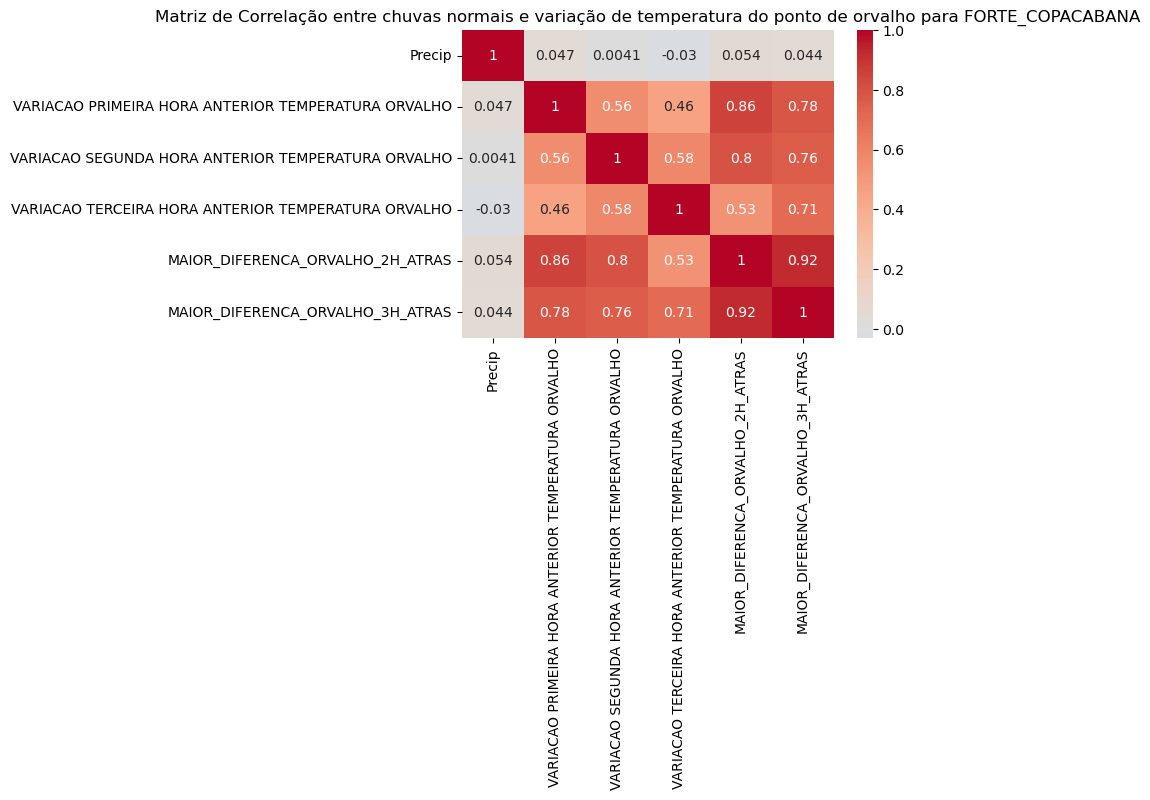

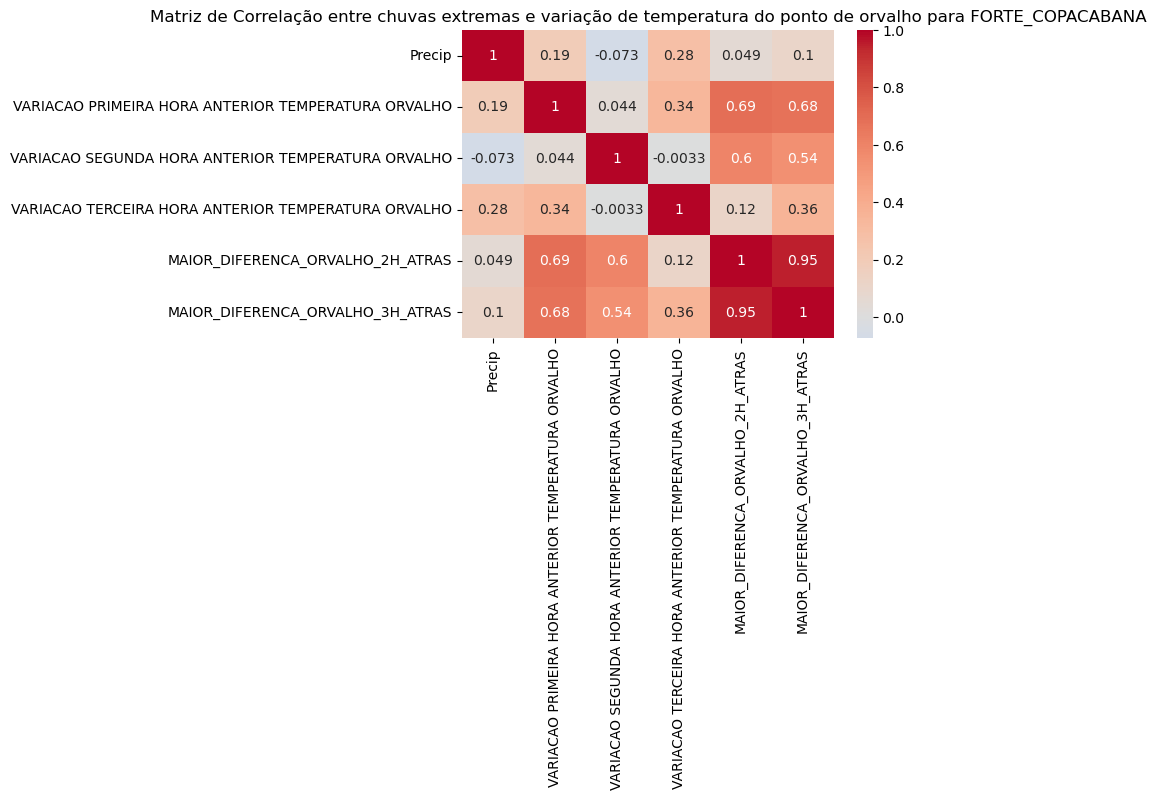


Estatísticas Descritivas para Chuvas Normais em FORTE_COPACABANA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,11397.000000,11397.000000,11397.000000,11397.000000,11397.000000,11397.000000
mean,1.399684,0.816434,0.790340,0.783162,1.148346,1.395464
std,2.478754,0.647198,0.621237,0.625217,0.834782,0.955551
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,0.200000,0.400000,0.400000,0.400000,0.600000,0.800000
50%,0.600000,0.600000,0.600000,0.600000,0.900000,1.200000
75%,1.400000,1.000000,1.000000,1.000000,1.400000,1.800000
max,24.800000,11.000000,7.000000,11.000000,11.700000,11.900000



Estatísticas Descritivas para Chuvas Extremas em FORTE_COPACABANA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,45.000000,45.000000,44.000000,44.000000,45.000000,45.000000
mean,37.235556,1.351111,1.106818,0.865909,1.968889,2.271111
std,11.731565,0.697275,0.830074,0.569350,1.054605,1.193852
min,25.200000,0.400000,0.300000,0.200000,0.700000,0.700000
25%,29.000000,0.800000,0.500000,0.500000,1.300000,1.500000
50%,34.200000,1.200000,0.800000,0.650000,1.800000,1.900000
75%,39.000000,1.700000,1.525000,0.925000,2.300000,2.700000
max,71.600000,3.200000,4.300000,2.700000,5.700000,6.700000


In [60]:
processar_estacao(df, 'FORTE_COPACABANA')

# Temos valores bizarros devido o -999 dos valores ausentes, removido


# Dispersão: Forte de copabana

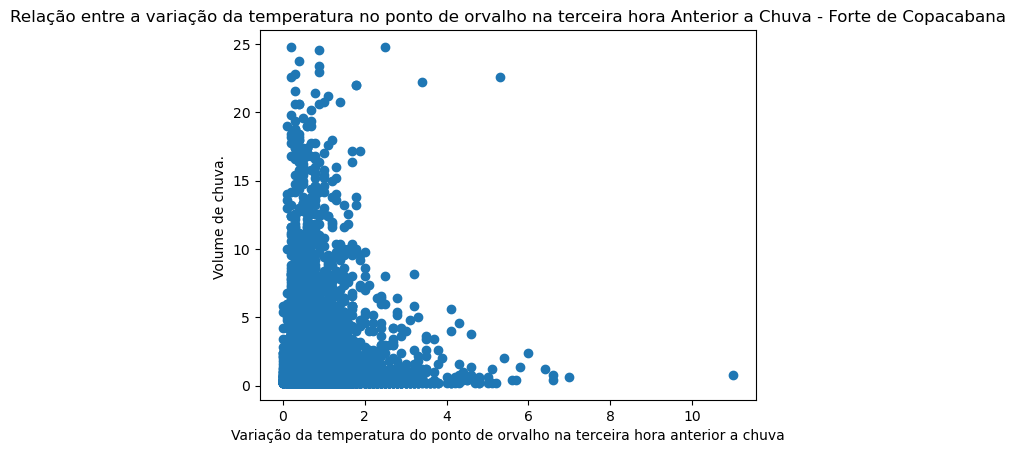

In [63]:
plt.scatter(FORTE_COPACABANA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], FORTE_COPACABANA_CHUVA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na terceira hora Anterior a Chuva - Forte de Copacabana')

plt.show()

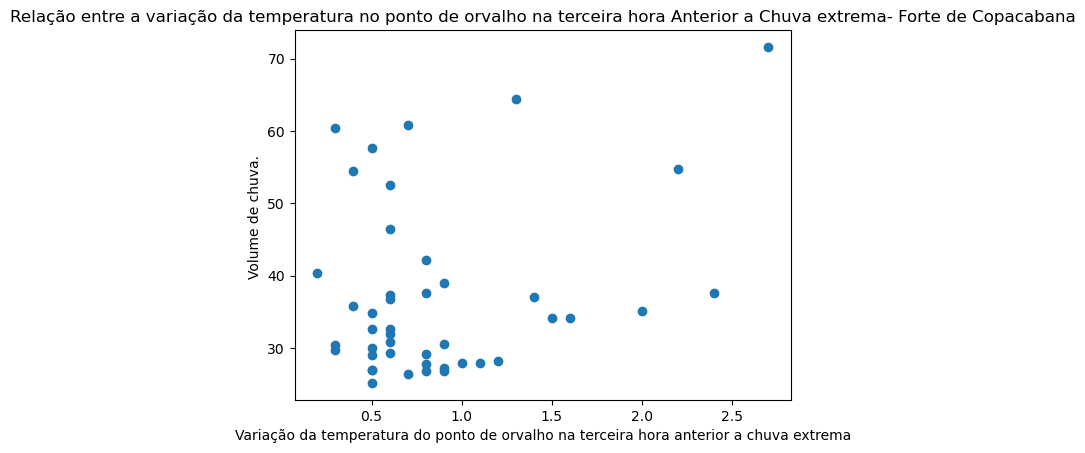

In [65]:
plt.scatter(FORTE_COPACABANA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], FORTE_COPACABANA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na terceira hora Anterior a Chuva extrema- Forte de Copacabana')

plt.show()

# Avaliando correlação de temperatura do ponto de orvalho: JACAREPAGUA

Dt_Hr                                                    0
ESTACAO                                                  0
Precip                                                 729
Pto_Orv_max                                            750
Pto_Orv_min                                            750
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO    705
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO     706
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO    707
dtype: int64
Total de valores nulos no DataFrame: 4347


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15636\651771882.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


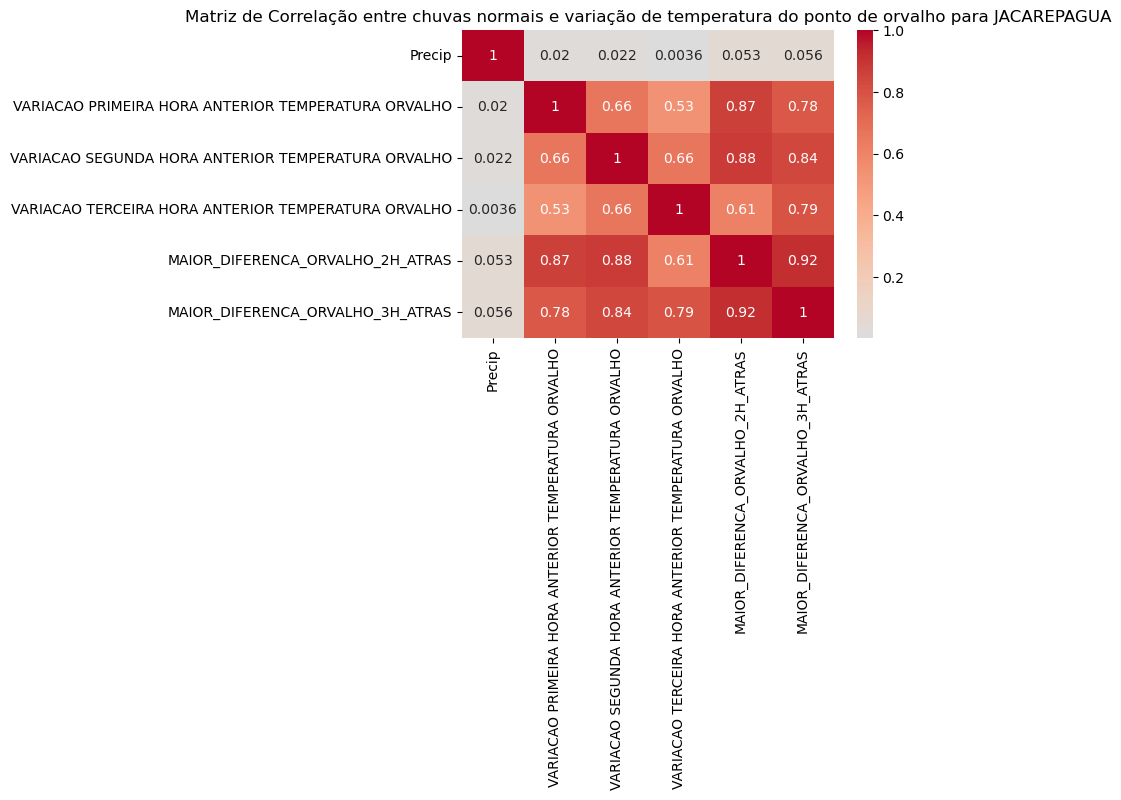

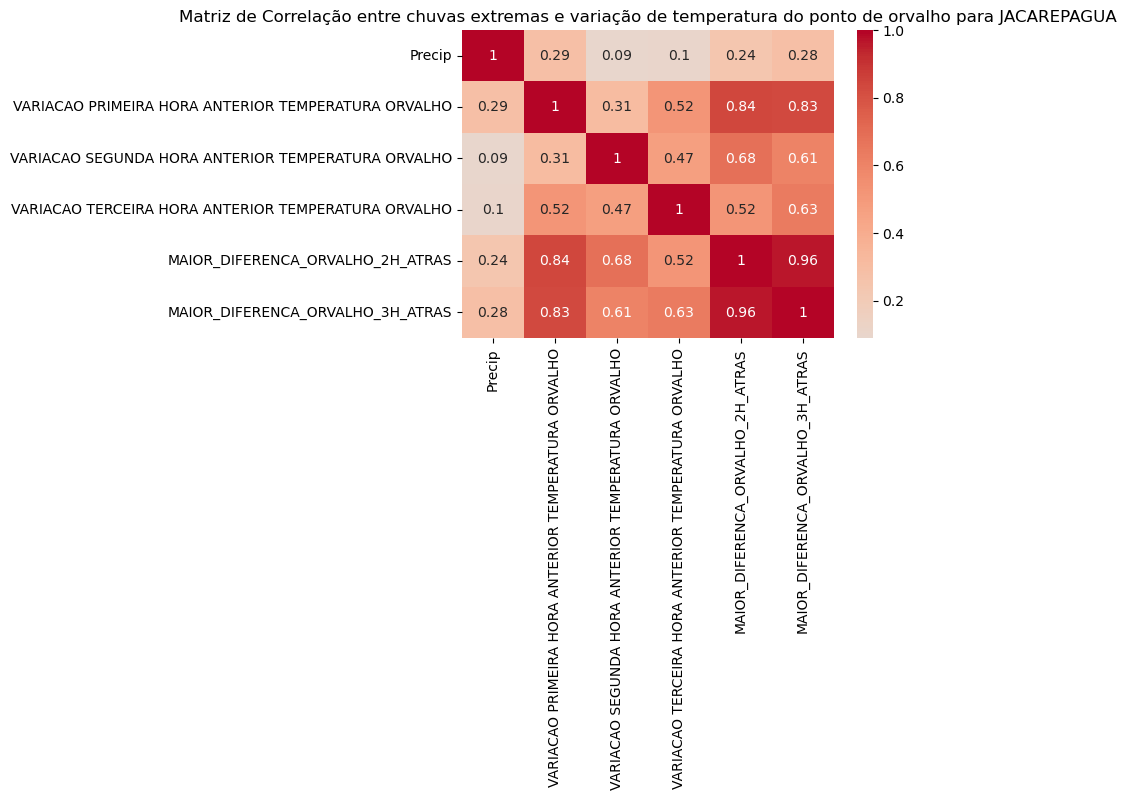


Estatísticas Descritivas para Chuvas Normais em JACAREPAGUA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,5614.000000,5614.000000,5614.000000,5614.000000,5614.000000,5614.000000
mean,1.742465,0.706270,0.728215,0.746990,1.051211,1.325009
std,2.867900,0.649782,0.686145,0.694844,0.874539,1.019364
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.500000,0.600000
50%,0.600000,0.500000,0.500000,0.500000,0.800000,1.000000
75%,2.000000,0.900000,0.900000,0.900000,1.300000,1.700000
max,24.800000,6.800000,7.000000,7.600000,8.800000,8.800000



Estatísticas Descritivas para Chuvas Extremas em JACAREPAGUA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,35.548387,1.212903,0.964516,0.838710,1.729032,1.935484
std,11.095461,0.973565,1.007488,0.761874,1.200054,1.286999
min,25.200000,0.100000,0.100000,0.100000,0.400000,0.400000
25%,28.400000,0.500000,0.350000,0.350000,0.800000,0.950000
50%,32.000000,0.800000,0.600000,0.600000,1.300000,1.500000
75%,38.600000,1.600000,1.200000,1.050000,2.350000,2.800000
max,80.200000,3.700000,4.400000,3.400000,4.600000,5.100000


In [75]:
processar_estacao(df, 'JACAREPAGUA')


# Dispersão: Jacarepagua

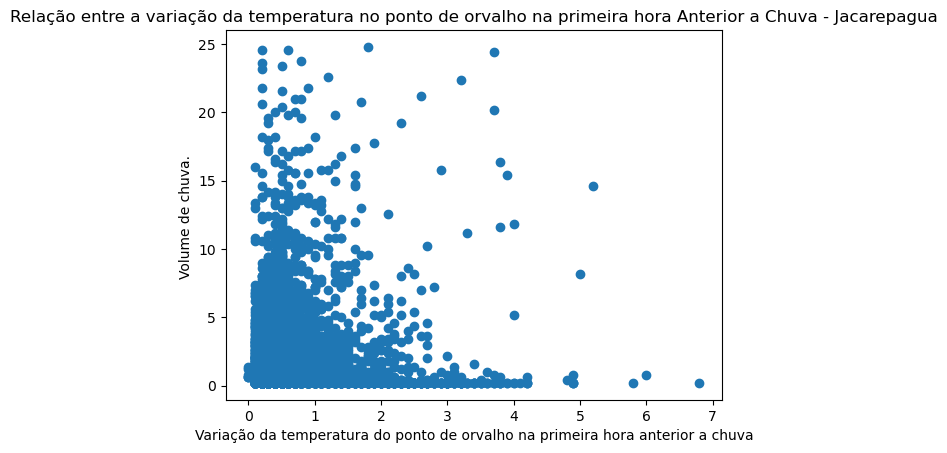

In [82]:
plt.scatter(JACAREPAGUA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], JACAREPAGUA_CHUVA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na primeira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na primeira hora Anterior a Chuva - Jacarepagua')

plt.show()

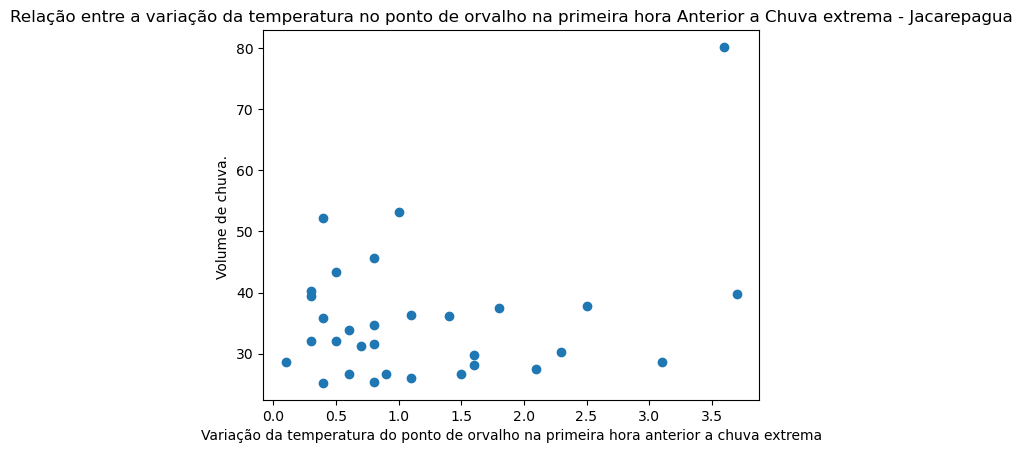

In [85]:
plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na primeira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na primeira hora Anterior a Chuva extrema - Jacarepagua')

plt.show()

# Avaliando correlação de temperatura do ponto de orvalho: MARAMBAIA

Dt_Hr                                                      0
ESTACAO                                                    0
Precip                                                 17701
Pto_Orv_max                                            47841
Pto_Orv_min                                            48560
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO    17830
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO     17831
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO    17832
dtype: int64
Total de valores nulos no DataFrame: 167595


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15636\651771882.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


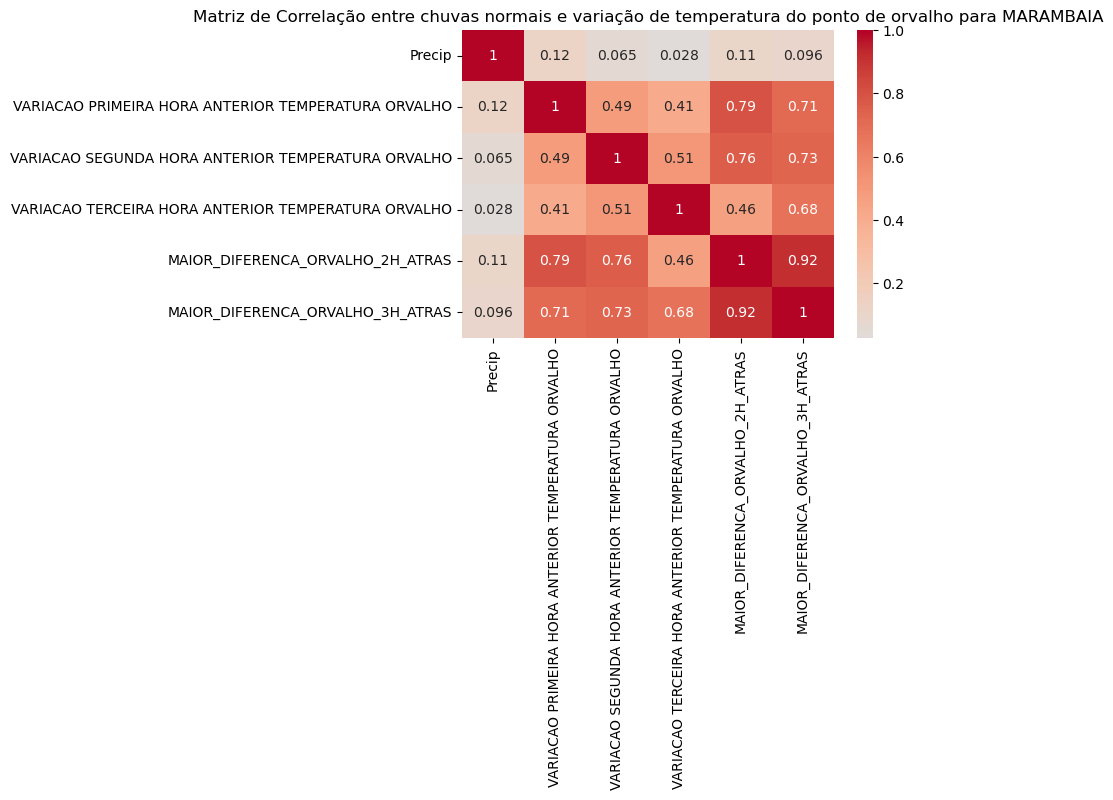

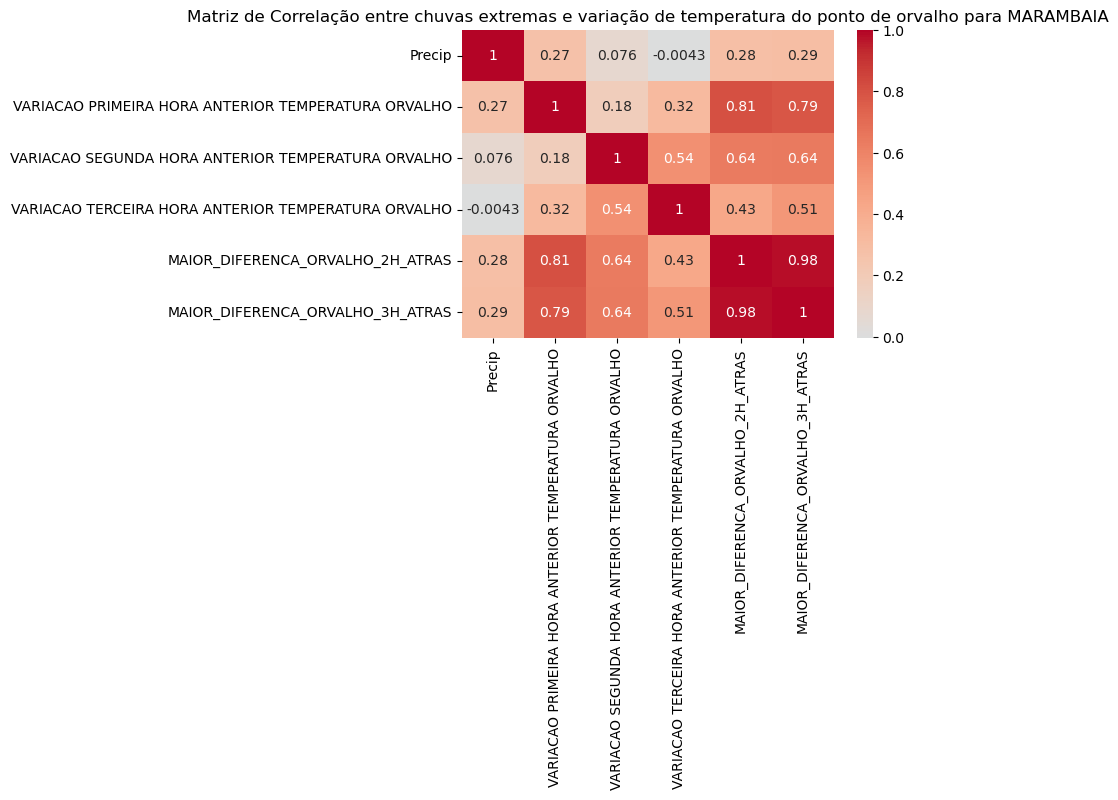


Estatísticas Descritivas para Chuvas Normais em MARAMBAIA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,11046.000000,11046.000000,11046.000000,11046.000000,11046.000000,11046.000000
mean,1.487054,0.759451,0.741191,0.736439,1.087199,1.326362
std,2.527860,0.634540,0.625270,0.626582,0.859037,0.967422
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.400000,0.400000,0.400000,0.600000,0.700000
50%,0.600000,0.600000,0.600000,0.600000,0.900000,1.100000
75%,1.600000,1.000000,0.900000,0.900000,1.400000,1.700000
max,24.600000,13.900000,13.900000,16.800000,28.100000,28.100000



Estatísticas Descritivas para Chuvas Extremas em MARAMBAIA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,42.000000,42.000000,42.000000,42.00000,42.000000,42.000000
mean,39.528571,1.471429,1.152381,0.85000,2.083333,2.271429
std,15.756675,1.053747,1.067305,0.67976,1.374669,1.369402
min,25.200000,0.300000,0.200000,0.00000,0.600000,0.600000
25%,29.500000,0.700000,0.525000,0.40000,1.025000,1.225000
50%,34.600000,1.100000,0.700000,0.70000,1.350000,1.700000
75%,46.450000,1.875000,1.225000,1.20000,2.875000,3.175000
max,97.200000,4.400000,5.100000,2.90000,5.600000,6.000000


In [89]:
processar_estacao(df, 'MARAMBAIA')


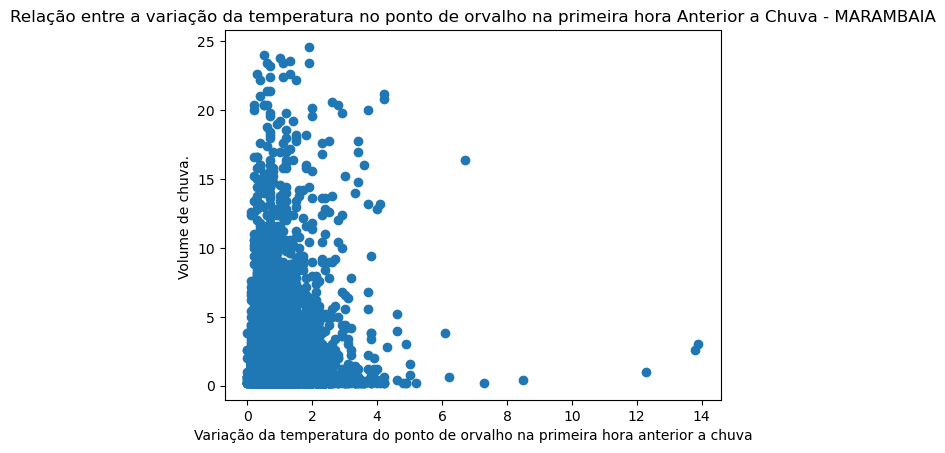

In [91]:
plt.scatter(MARAMBAIA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], MARAMBAIA_CHUVA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na primeira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na primeira hora Anterior a Chuva - MARAMBAIA')

plt.show()

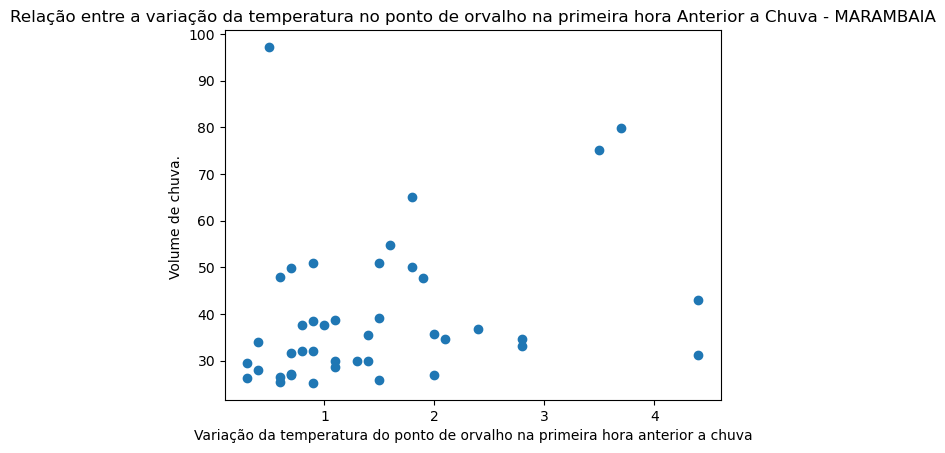

In [93]:
plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'], MARAMBAIA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na primeira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na primeira hora Anterior a Chuva - MARAMBAIA')

plt.show()

# Dispersão: VILA_MILITAR

Dt_Hr                                                     0
ESTACAO                                                   0
Precip                                                 5709
Pto_Orv_max                                            8641
Pto_Orv_min                                            8659
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO    3956
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO     3957
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO    3958
dtype: int64
Total de valores nulos no DataFrame: 34880


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15636\651771882.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


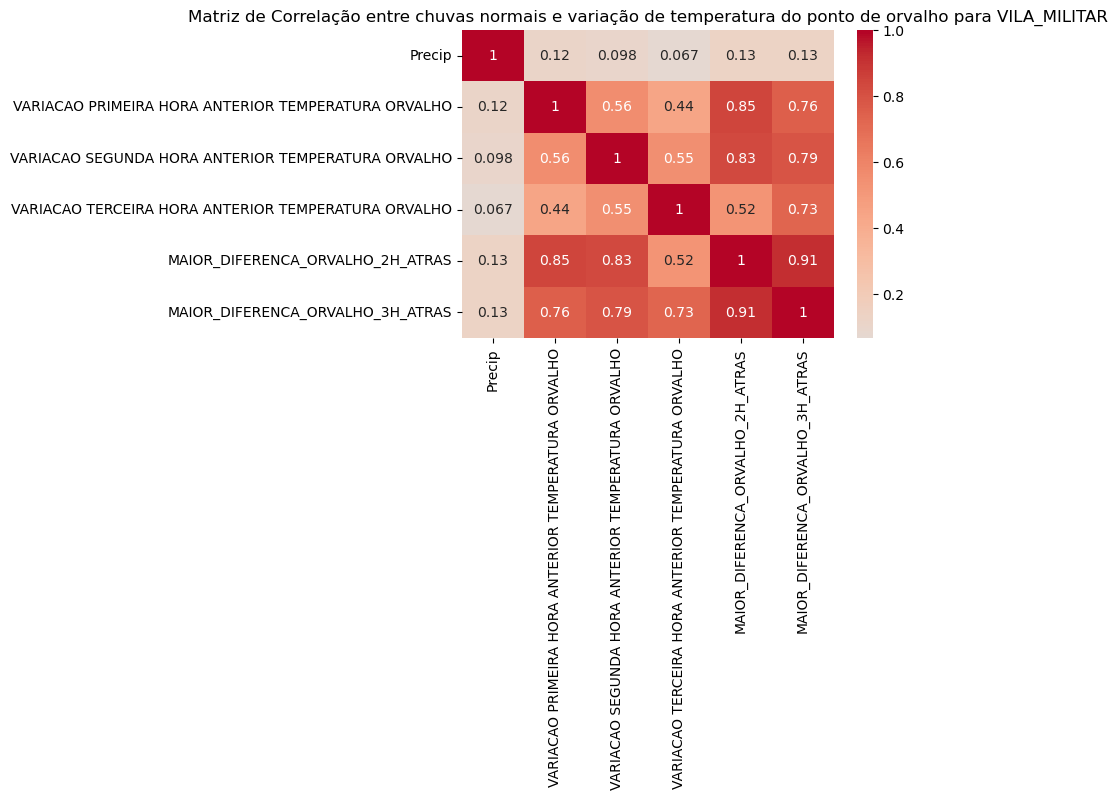

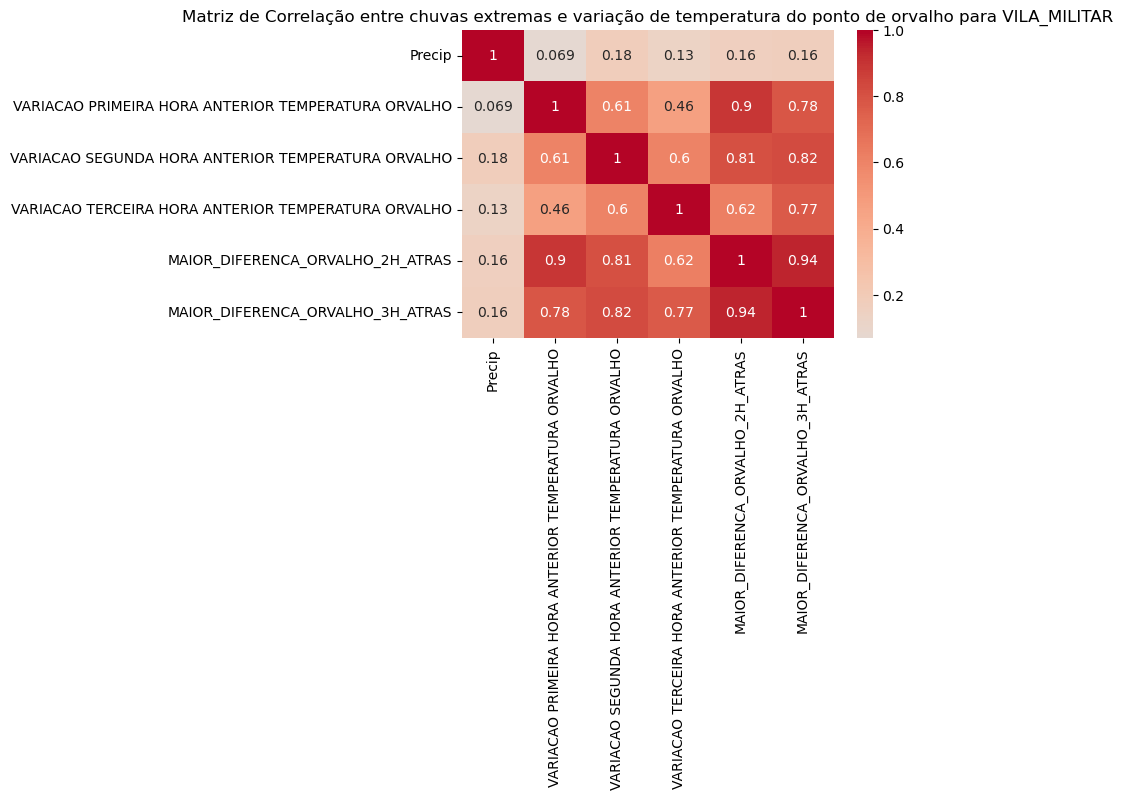


Estatísticas Descritivas para Chuvas Normais em VILA_MILITAR:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000
mean,1.478415,0.863793,0.853150,0.855190,1.272387,1.581896
std,2.681918,0.761839,0.736819,0.715287,1.015678,1.167102
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.400000,0.400000,0.400000,0.600000,0.800000
50%,0.400000,0.600000,0.600000,0.600000,1.000000,1.300000
75%,1.400000,1.100000,1.100000,1.100000,1.600000,2.000000
max,24.800000,12.400000,12.400000,7.100000,13.100000,13.100000



Estatísticas Descritivas para Chuvas Extremas em VILA_MILITAR:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,MAIOR_DIFERENCA_ORVALHO_2H_ATRAS,MAIOR_DIFERENCA_ORVALHO_3H_ATRAS
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,35.120000,1.810000,1.517143,1.385714,2.424286,2.715714
std,8.875134,1.339062,1.190904,1.249613,1.534666,1.582846
min,25.000000,0.200000,0.100000,0.100000,0.400000,0.600000
25%,28.850000,0.700000,0.600000,0.500000,1.200000,1.325000
50%,31.800000,1.400000,1.050000,1.050000,2.450000,2.600000
75%,40.400000,2.600000,2.075000,1.975000,3.350000,3.550000
max,64.000000,6.400000,5.300000,6.900000,6.400000,6.900000


In [98]:
processar_estacao(df, 'VILA_MILITAR')


In [ ]:
# Dispersão: VILA_MILITAR

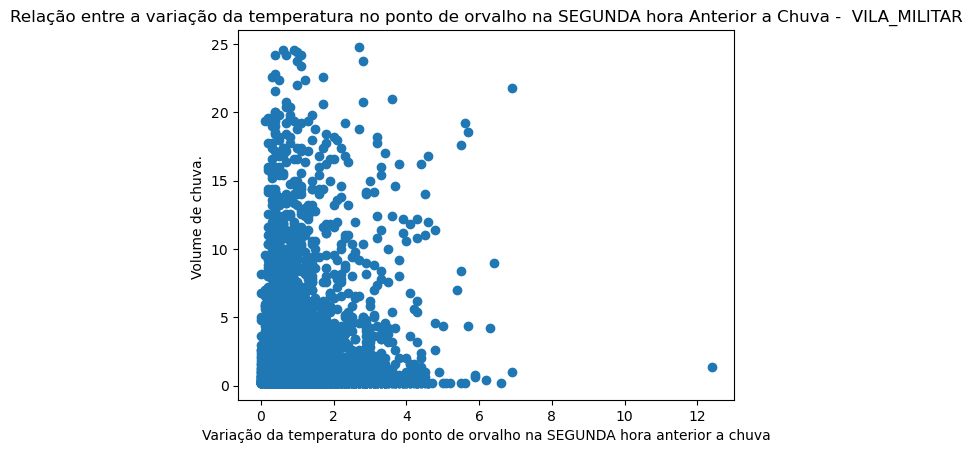

In [100]:
plt.scatter( VILA_MILITAR_CHUVA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO'],  VILA_MILITAR_CHUVA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na SEGUNDA hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na SEGUNDA hora Anterior a Chuva -  VILA_MILITAR')

plt.show()

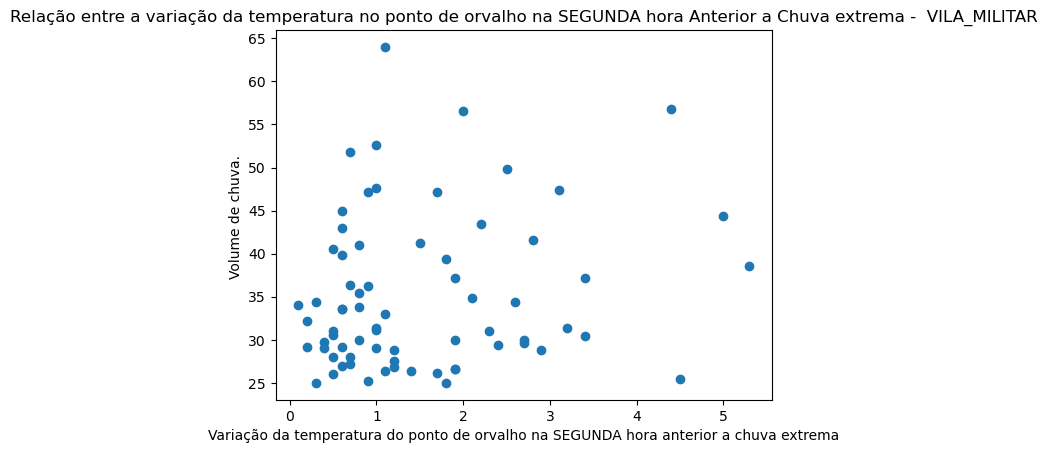

In [102]:
plt.scatter( VILA_MILITAR_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO'],  VILA_MILITAR_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação da temperatura do ponto de orvalho na SEGUNDA hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre a variação da temperatura no ponto de orvalho na SEGUNDA hora Anterior a Chuva extrema -  VILA_MILITAR')

plt.show()